# Experiment 4: Exploratory Data Analysis & Visualization
This notebook demonstrates EDA steps including data generation, metrics, visualization, and insights.

In [ ]:
# Step 1: Install required libraries (run only if needed)
pip install pandas numpy matplotlib seaborn wordcloud

In [3]:
# Step 2: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import random

sns.set_style('whitegrid')
%matplotlib inline

In [4]:
# Step 3: Generate Data
np.random.seed(123)
random.seed(123)

dates = pd.date_range(start='2025-01-01', periods=200, freq='D')

df = pd.DataFrame({
    'date': np.random.choice(dates, 200),
    'likes': np.random.randint(20, 800, 200),
    'comments': np.random.randint(5, 200, 200),
    'shares': np.random.randint(0, 150, 200),
    'followers': np.random.randint(1000, 20000, 200)
})

themes = [
    "Great product launch", "New discount offer", "Customer feedback",
    "Behind the scenes", "Happy clients", "Product update", "Special event"
]

df['caption'] = np.random.choice(themes, 200)

df['text_for_wordcloud'] = df['caption'] + " " + np.random.choice(
    ["amazing", "awesome", "love", "great", "bad", "issue", "discount", "offer"], 200
)

In [5]:
# Step 4: Engagement Metrics
df['engagement'] = df['likes'] + df['comments'] + df['shares']
df['engagement_rate'] = df['engagement'] / df['followers']

df['date'] = pd.to_datetime(df['date'])
df['day'] = df['date'].dt.day_name()
df['month'] = df['date'].dt.month

df.head()

,date,likes,comments,shares,followers,caption,text_for_wordcloud,engagement,engagement_rate,day,month
0,2025-04-20,577,83,136,13730,Special event,Special event amazing,796,0.057975,Sunday,4
1,2025-05-07,654,116,22,15168,Product update,Product update bad,792,0.052215,Wednesday,5
2,2025-03-08,462,26,148,6106,Behind the scenes,Behind the scenes love,636,0.104160,Saturday,3
3,2025-04-09,207,163,108,12495,Happy clients,Happy clients great,478,0.038255,Wednesday,4
4,2025-01-18,427,192,32,2487,New discount offer,New discount offer great,651,0.261761,Saturday,1


In [6]:
# Step 5: Summary Statistics
df.describe()

,date,likes,comments,shares,followers,engagement,engagement_rate,month
count,200,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,2025-04-11 19:40:48,415.020000,99.690000,72.700000,10656.765000,587.410000,0.088928,3.895000
min,2025-01-01 00:00:00,21.000000,5.000000,0.000000,1109.000000,64.000000,0.010241,1.000000
25%,2025-02-27 18:00:00,241.500000,44.000000,29.000000,4793.500000,419.250000,0.037852,2.000000
50%,2025-04-12 00:00:00,426.000000,98.500000,77.000000,10634.500000,587.000000,0.051975,4.000000
75%,2025-05-26 06:00:00,600.000000,152.250000,110.000000,16276.000000,761.750000,0.107826,5.000000
max,2025-07-19 00:00:00,791.000000,199.000000,148.000000,19831.000000,1117.000000,0.854288,7.000000
std,NaN,215.991577,59.757667,44.128866,5959.866957,222.965919,0.094768,1.838717


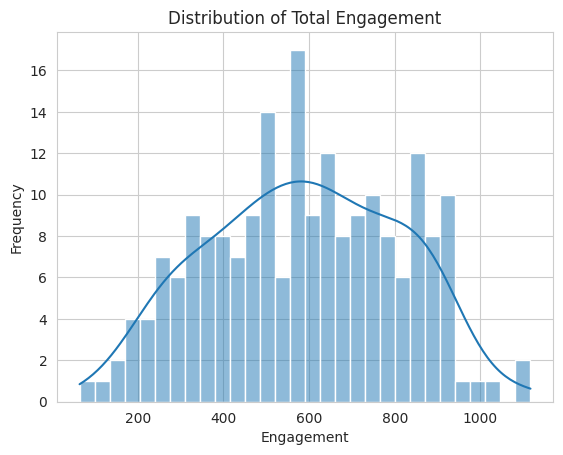

In [7]:
# Step 6: Histogram
plt.figure()
sns.histplot(df['engagement'], bins=30, kde=True)
plt.title('Distribution of Total Engagement')
plt.xlabel('Engagement')
plt.ylabel('Frequency')
plt.show()

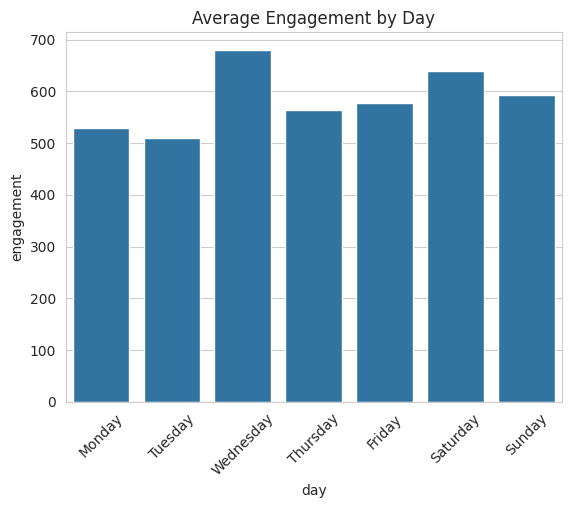

In [8]:
# Step 7: Engagement by Day
order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
plt.figure()
sns.barplot(x='day', y='engagement', data=df, order=order, errorbar=None)
plt.xticks(rotation=45)
plt.title('Average Engagement by Day')
plt.show()

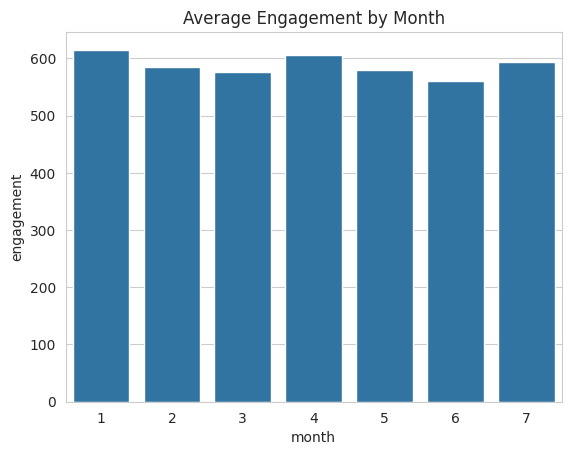

In [9]:
# Step 8: Engagement by Month
plt.figure()
sns.barplot(x='month', y='engagement', data=df, errorbar=None)
plt.title('Average Engagement by Month')
plt.show()

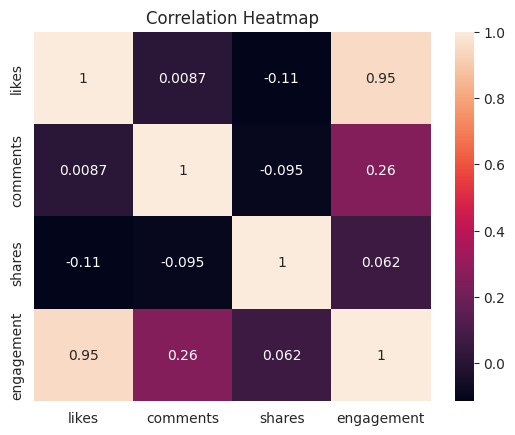

In [10]:
# Step 9: Correlation Heatmap
plt.figure()
corr = df[['likes','comments','shares','engagement']].corr()
sns.heatmap(corr, annot=True)
plt.title('Correlation Heatmap')
plt.show()

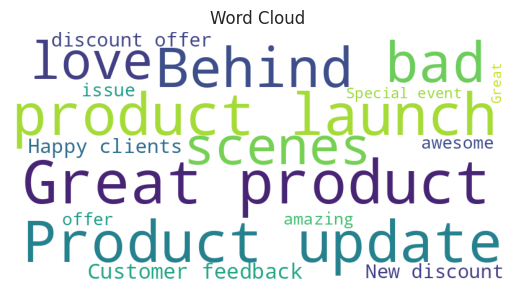

In [11]:
# Step 10: Word Cloud
text = " ".join(df['text_for_wordcloud'])
wc = WordCloud(width=800, height=400, background_color='white').generate(text)
plt.figure()
plt.imshow(wc)
plt.axis('off')
plt.title('Word Cloud')
plt.show()

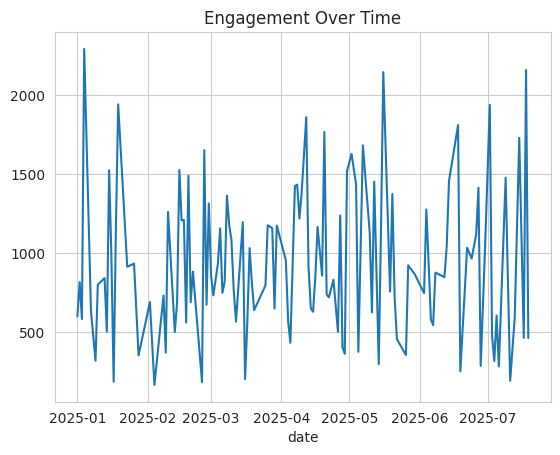

In [12]:
# Step 11: Trend Over Time
daily = df.groupby(df['date'].dt.date)['engagement'].sum()
plt.figure()
daily.plot()
plt.title('Engagement Over Time')
plt.show()

In [13]:
# Step 12: Insights
print('Insights:')
print('- Most posts have engagement between 200 and 600')
print('- Engagement peaks mid-week')
print('- Likes strongly influence engagement')

Insights:
- Most posts have engagement between 200 and 600
- Engagement peaks mid-week
- Likes strongly influence engagement
